# Perturbation x Pipeline Step Heatmaps

Heatmaps showing how different perturbations affect each step of the data science pipeline,
extracted from `pairwise_analysis.ipynb`.

In [77]:
import os, sys
from os.path import join as pjoin
import json
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

root_dir = "/accounts/campus/austin.zane/stat-genie"

os.chdir(root_dir)
sys.path.insert(0, root_dir)

analysis_dir = pjoin(root_dir, "experiments", "outputs", "analysis")
pairwise_eval_dir = pjoin(root_dir, "experiments", "outputs", "pairwise_eval")


perturbation_mapping = {
    0: "add_features",
    1: "anonymize",
    2: "noperturb",
    3: "replace_with_rvs",
    4: "shuffle_names",
    5: "positive_leading_statement",
    6: "negative_leading_statement",
    7: "replace_and_positive_statement"
}

perturbation_to_int = {v: k for k, v in perturbation_mapping.items()}

perturbations = perturbation_to_int.keys()
baseline_perturbation = "noperturb"
baseline_idx = perturbation_to_int[baseline_perturbation]
baseline_within_string = f"within:{baseline_perturbation}"

all_datasets = os.listdir(analysis_dir)
datasets = [d for d in all_datasets if os.path.exists(pjoin(pairwise_eval_dir, d))]
print(f"{len(datasets)} datasets: {datasets}")

10 datasets: ['caschools', 'soccer', 'crofoot', 'hurricane', 'amtl', 'teachingratings', 'affairs', 'boxes', 'panda_nuts', 'mortgage']


In [78]:
# Parse pairwise evaluation JSON files
# Keys: 'i_j' = perturbation i vs j, 'k_l' = run k vs run l

exclude_idxs = {k for k, v in perturbation_mapping.items() if "replace" in v}

rows = []

for dataset in datasets:
    if not os.path.exists(pjoin(pairwise_eval_dir, dataset)):
        continue
    try:
        job_id = os.listdir(pjoin(pairwise_eval_dir, dataset))[0]
        json_path = pjoin(pairwise_eval_dir, dataset, job_id, "pairwise_similarities.json")
        
        with open(json_path, "r") as f:
            pairwise_eval = json.load(f)
    except (FileNotFoundError, IndexError, KeyError) as e:
        print(f"Skipping {dataset}")
        continue
    
    for pert_key, inner_dict in pairwise_eval.items():
        parts_pert = pert_key.split('_')
        perturbation_i = int(parts_pert[0])
        perturbation_j = int(parts_pert[1])
        
        if perturbation_i in exclude_idxs or perturbation_j in exclude_idxs:
            continue
        
        for run_key, scores_dict in inner_dict.items():
            parts_run = run_key.split('_')
            run_i = int(parts_run[0])
            run_j = int(parts_run[1])
            
            # Skip self-comparisons (same perturbation, same run)
            if perturbation_i == perturbation_j and run_i == run_j:
                continue
            
            row = {
                'dataset': dataset,
                'perturbation_i': perturbation_i,
                'perturbation_j': perturbation_j,
                'run_i': run_i,
                'run_j': run_j,
                'iv_score': scores_dict.get('Independent Variables Similarity Score'),
                'cv_score': scores_dict.get('Control Variables Similarity Score'),
                'model_score': scores_dict.get('Model Similarity Score'),
                'conclusion_score': scores_dict.get('conclusions'),
                'overall_score': scores_dict.get('overall_similarity')
            }
            rows.append(row)

df_pairwise = pd.DataFrame(rows)

def get_perturbation_pair_type(row):
    pert_i = row['perturbation_i']
    pert_j = row['perturbation_j']
    name_i = perturbation_mapping[pert_i]
    name_j = perturbation_mapping[pert_j]
    
    if pert_i == pert_j:
        return f'within:{name_i}'
    elif pert_i == baseline_idx:
        return f'baseline_vs:{name_j}'
    elif pert_j == baseline_idx:
        return f'baseline_vs:{name_i}'
    else:
        return f'between:{name_i}__{name_j}'

df_pairwise['perturbation_pair_type'] = df_pairwise.apply(get_perturbation_pair_type, axis=1)

print(f"{len(df_pairwise)} rows")
print(f"\n{df_pairwise['perturbation_pair_type'].value_counts()}")

2850 rows

between:anonymize__negative_leading_statement                     150
between:shuffle_names__positive_leading_statement                 150
baseline_vs:add_features                                          150
between:add_features__shuffle_names                               150
between:add_features__positive_leading_statement                  150
between:add_features__negative_leading_statement                  150
between:positive_leading_statement__negative_leading_statement    150
baseline_vs:anonymize                                             150
between:anonymize__shuffle_names                                  150
between:anonymize__positive_leading_statement                     150
between:add_features__anonymize                                   150
baseline_vs:shuffle_names                                         150
baseline_vs:positive_leading_statement                            150
baseline_vs:negative_leading_statement                            150
between:s

In [79]:
score_cols = [
    "iv_score",
    "cv_score",
    "model_score",
    "conclusion_score",
]

long_df = df_pairwise.melt(
    id_vars=["dataset", "perturbation_pair_type"],
    value_vars=score_cols,
    var_name="step",
    value_name="score",
)

long_df["step"] = long_df["step"].str.replace("_score", "")


long_df["perturbation_pair_type"] = (
    long_df["perturbation_pair_type"].astype("category")
)
long_df["step"] = long_df["step"].astype("category")
long_df["dataset"] = long_df["dataset"].astype("category")

new_order = (
    [baseline_within_string] +
    [c for c in long_df["perturbation_pair_type"].cat.categories if c != baseline_within_string]
)

long_df["perturbation_pair_type"] = (
    long_df["perturbation_pair_type"]
    .cat.reorder_categories(new_order, ordered=False)
)

# Reversed so origin="lower" renders top-to-bottom as: iv, cv, model, conclusion
step_order = ["conclusion", "model", "cv", "iv"]
long_df["step"] = long_df["step"].cat.reorder_categories(step_order, ordered=False)

In [80]:
# Compute per-step delta relative to within-baseline mean
baseline = (
    long_df[long_df["perturbation_pair_type"] == baseline_within_string]
    .groupby(["dataset", "step"])["score"]
    .mean()
    .reset_index()
    .rename(columns={"score": "baseline_score"})
)
merged = long_df.merge(
    baseline,
    on=["dataset", "step"],
    how="left"
)

merged["delta"] = merged["score"] - merged["baseline_score"]

heatmap_df = (
    merged.groupby(["step", "perturbation_pair_type"])["delta"]
    .mean()
    .unstack()
)

mask = heatmap_df.columns.str.startswith("between")
heatmap_df_filtered = heatmap_df.loc[:, ~mask]

# Column ordering: baseline first, then within, then baseline_vs
non_baseline_perturbations = sorted([p for p in perturbation_to_int.keys() if p != baseline_perturbation])

desired_order = [baseline_within_string]
for pert_name in non_baseline_perturbations:
    desired_order.append(f'within:{pert_name}')
for pert_name in non_baseline_perturbations:
    desired_order.append(f'baseline_vs:{pert_name}')

available_cols = [col for col in desired_order if col in heatmap_df_filtered.columns]
heatmap_df_filtered = heatmap_df_filtered[available_cols]

print(heatmap_df_filtered)

perturbation_pair_type  within:noperturb  within:add_features  \
step                                                            
conclusion                  0.000000e+00         2.400000e-01   
model                       1.509903e-16        -1.900000e-01   
cv                          3.552714e-17        -1.400000e-01   
iv                         -8.881784e-17        -8.881784e-17   

perturbation_pair_type  within:anonymize  within:negative_leading_statement  \
step                                                                          
conclusion                         -0.36                               0.14   
model                              -0.14                               0.20   
cv                                  0.05                               0.06   
iv                                  0.05                               0.03   

perturbation_pair_type  within:positive_leading_statement  \
step                                                        
conclusion  

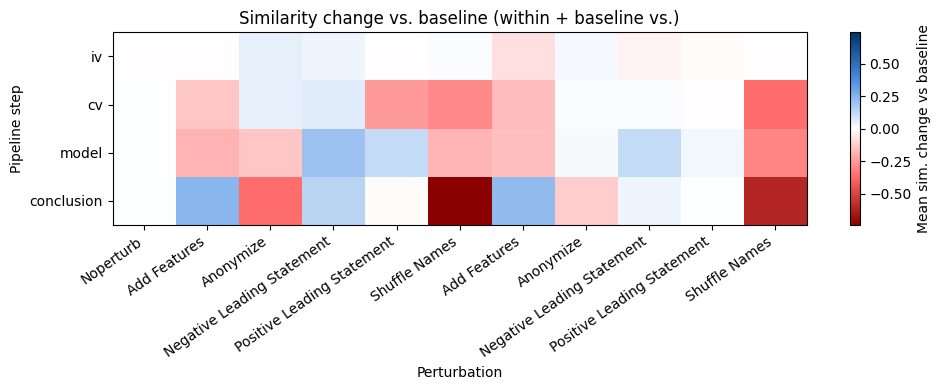

In [81]:
# Shared colormap for signed-delta heatmaps
colors = ['#8b0000', '#ff6b6b', '#ffffff', '#4a90e2', '#003366']
cmap = LinearSegmentedColormap.from_list('red_white_blue', colors, N=256)

data = heatmap_df_filtered.values
vmin, vmax = data.min(), data.max()
abs_max = max(abs(vmin), abs(vmax))
norm = TwoSlopeNorm(vmin=-abs_max, vcenter=0, vmax=abs_max)

def pretty_label(name):
    return name.replace("_", " ").title()

combined_labels = [pretty_label(c.split(":", 1)[1]) for c in heatmap_df_filtered.columns]

fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(
    heatmap_df_filtered.values,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    norm=norm,
)

ax.set_xticks(np.arange(heatmap_df_filtered.shape[1]))
ax.set_yticks(np.arange(heatmap_df_filtered.shape[0]))

ax.set_xticklabels(combined_labels, rotation=35, ha="right")
ax.set_yticklabels(heatmap_df_filtered.index)

ax.set_title("Similarity change vs. baseline (within + baseline vs.)")
ax.set_xlabel("Perturbation")
ax.set_ylabel("Pipeline step")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Mean sim. change vs baseline")

plt.tight_layout()
plt.show()

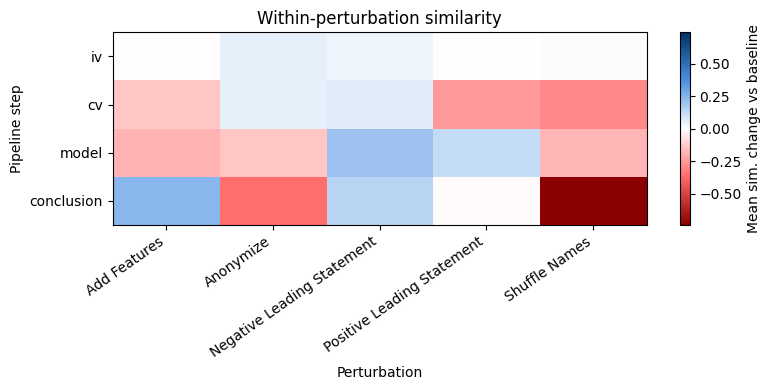

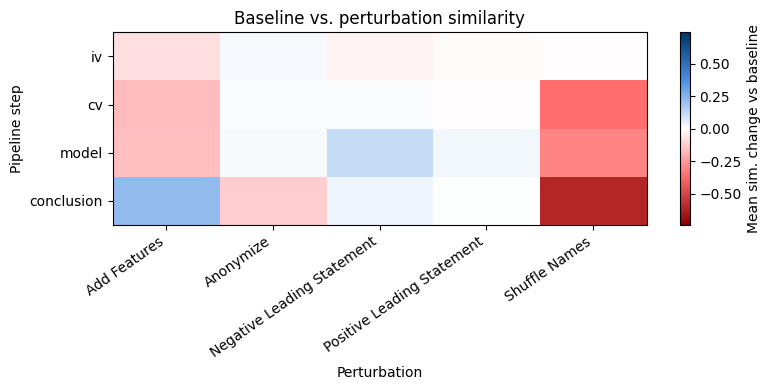

In [82]:
# Split into within and baseline_vs heatmaps
within_cols = [col for col in heatmap_df_filtered.columns if col.startswith('within:')]
baseline_vs_cols = [col for col in heatmap_df_filtered.columns if col.startswith('baseline_vs:')]

heatmap_within = heatmap_df_filtered[within_cols]
heatmap_baseline_vs = heatmap_df_filtered[baseline_vs_cols]

heatmap_within = heatmap_within.drop(columns=[baseline_within_string], errors='ignore')

# Strip prefixes for cleaner labels
within_labels = [pretty_label(c.replace("within:", "")) for c in heatmap_within.columns]
baseline_vs_labels = [pretty_label(c.replace("baseline_vs:", "")) for c in heatmap_baseline_vs.columns]

fig_dir = pjoin(root_dir, "experiments", "insights", "figures")

fig1, ax1 = plt.subplots(figsize=(8, 4))

im1 = ax1.imshow(
    heatmap_within.values,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    norm=norm,
)

ax1.set_xticks(np.arange(heatmap_within.shape[1]))
ax1.set_yticks(np.arange(heatmap_within.shape[0]))
ax1.set_xticklabels(within_labels, rotation=35, ha="right")
ax1.set_yticklabels(heatmap_within.index)
ax1.set_title("Within-perturbation similarity")
ax1.set_xlabel("Perturbation")
ax1.set_ylabel("Pipeline step")

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("Mean sim. change vs baseline")

plt.tight_layout()
fig1.savefig(pjoin(fig_dir, "signed_within_perturbation.pdf"), bbox_inches="tight")
plt.show()

# baseline_vs heatmap
fig2, ax2 = plt.subplots(figsize=(8, 4))

im2 = ax2.imshow(
    heatmap_baseline_vs.values,
    aspect="auto",
    origin="lower",
    cmap=cmap,
    norm=norm,
)

ax2.set_xticks(np.arange(heatmap_baseline_vs.shape[1]))
ax2.set_yticks(np.arange(heatmap_baseline_vs.shape[0]))
ax2.set_xticklabels(baseline_vs_labels, rotation=35, ha="right")
ax2.set_yticklabels(heatmap_baseline_vs.index)
ax2.set_title("Baseline vs. perturbation similarity")
ax2.set_xlabel("Perturbation")
ax2.set_ylabel("Pipeline step")

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label("Mean sim. change vs baseline")

plt.tight_layout()
fig2.savefig(pjoin(fig_dir, "signed_baseline_vs_perturbation.pdf"), bbox_inches="tight")
plt.show()

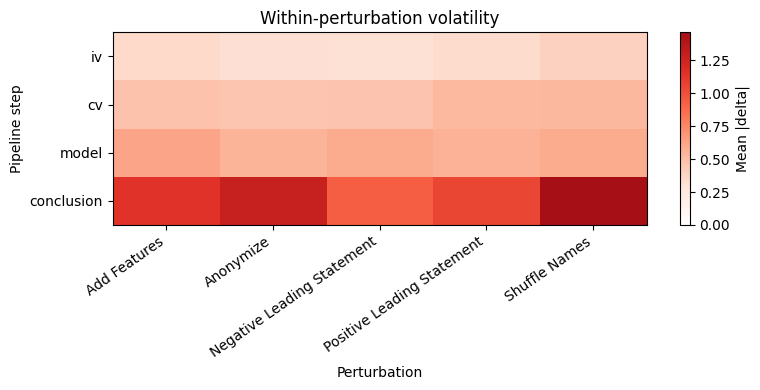

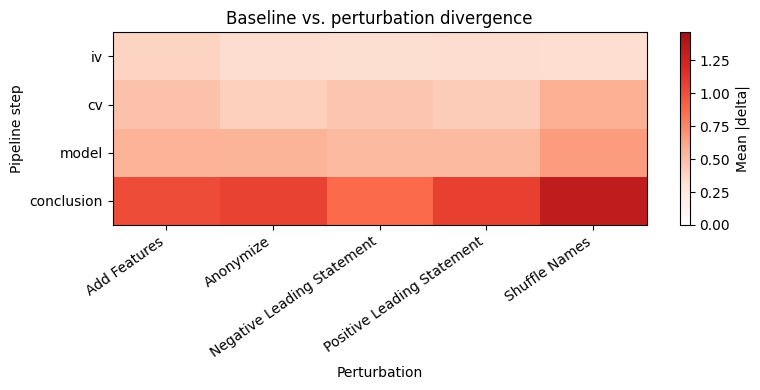

In [83]:
# Mean absolute delta (magnitude regardless of direction)
heatmap_abs_df = (
    merged.groupby(["step", "perturbation_pair_type"])["delta"]
    .apply(lambda x: np.abs(x).mean())
    .unstack()
)

mask_abs = heatmap_abs_df.columns.str.startswith("between")
heatmap_abs_filtered = heatmap_abs_df.loc[:, ~mask_abs]

available_cols_abs = [col for col in desired_order if col in heatmap_abs_filtered.columns]
heatmap_abs_filtered = heatmap_abs_filtered[available_cols_abs]

# Split into within and baseline_vs
within_cols_abs = [col for col in heatmap_abs_filtered.columns if col.startswith('within:')]
baseline_vs_cols_abs = [col for col in heatmap_abs_filtered.columns if col.startswith('baseline_vs:')]

heatmap_abs_within = heatmap_abs_filtered[within_cols_abs]
heatmap_abs_baseline_vs = heatmap_abs_filtered[baseline_vs_cols_abs]

heatmap_abs_within = heatmap_abs_within.drop(columns=[baseline_within_string], errors='ignore')

within_labels_abs = [pretty_label(c.replace("within:", "")) for c in heatmap_abs_within.columns]
baseline_vs_labels_abs = [pretty_label(c.replace("baseline_vs:", "")) for c in heatmap_abs_baseline_vs.columns]

colors_abs = ['#ffffff', '#fee5d9', '#fcae91', '#fb6a4a', '#de2d26', '#a50f15']
cmap_abs = LinearSegmentedColormap.from_list('white_to_dark', colors_abs, N=256)

# Shared scale across both panels
vmax_abs = max(heatmap_abs_within.values.max(), heatmap_abs_baseline_vs.values.max())

# Within-perturbation
fig1, ax1 = plt.subplots(figsize=(8, 4))

im1 = ax1.imshow(
    heatmap_abs_within.values,
    aspect="auto",
    origin="lower",
    cmap=cmap_abs,
    vmin=0,
    vmax=vmax_abs,
)

ax1.set_xticks(np.arange(heatmap_abs_within.shape[1]))
ax1.set_yticks(np.arange(heatmap_abs_within.shape[0]))
ax1.set_xticklabels(within_labels_abs, rotation=35, ha="right")
ax1.set_yticklabels(heatmap_abs_within.index)
ax1.set_title("Within-perturbation volatility")
ax1.set_xlabel("Perturbation")
ax1.set_ylabel("Pipeline step")

cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label("Mean |delta|")

plt.tight_layout()
fig1.savefig(pjoin(fig_dir, "abs_within_perturbation.pdf"), bbox_inches="tight")
plt.show()

# Baseline vs. perturbation
fig2, ax2 = plt.subplots(figsize=(8, 4))

im2 = ax2.imshow(
    heatmap_abs_baseline_vs.values,
    aspect="auto",
    origin="lower",
    cmap=cmap_abs,
    vmin=0,
    vmax=vmax_abs,
)

ax2.set_xticks(np.arange(heatmap_abs_baseline_vs.shape[1]))
ax2.set_yticks(np.arange(heatmap_abs_baseline_vs.shape[0]))
ax2.set_xticklabels(baseline_vs_labels_abs, rotation=35, ha="right")
ax2.set_yticklabels(heatmap_abs_baseline_vs.index)
ax2.set_title("Baseline vs. perturbation divergence")
ax2.set_xlabel("Perturbation")
ax2.set_ylabel("Pipeline step")

cbar2 = plt.colorbar(im2, ax=ax2)
cbar2.set_label("Mean |delta|")

plt.tight_layout()
fig2.savefig(pjoin(fig_dir, "abs_baseline_vs_perturbation.pdf"), bbox_inches="tight")
plt.show()